# <a id='toc1_'></a>[Topic 16: Bode Asymptotic Plots](#toc0_)

**Table of contents**<a id='toc0_'></a>    
- [Topic 16: Bode Asymptotic Plots](#toc1_)    
  - [First Order](#toc1_1_)    
  - [Second Order](#toc1_2_)    
  - [Examples 16-20](#toc1_3_)    
  - [Examples 16-24](#toc1_4_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

In [ ]:
# Course utilities (do not modify this cell)

from pathlib import Path
import sys

# repo_root/16_06_Class/notebooks → repo_root/16_06_Class
repo_root = Path.cwd().parents[0]
sys.path.insert(0, str(repo_root))

import courseutils.basic_material as bm
import courseutils.control_materials as cm

bm.setup_environment()
cm.setup_environment()

import numpy as np
import matplotlib.pyplot as plt
colors = bm.get_colors()

from scipy.optimize import fsolve


In [32]:
colors = bm.get_colors()

import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
import os
import control as ct
import control.matlab as cmat

import Approx_Bode as ab    

import warnings
warnings.filterwarnings(
    "ignore",
    message="divide by zero encountered in divide"
)
warnings.filterwarnings(
    "ignore",
    message="invalid value encountered in divide"
)

## <a id='toc1_1_'></a>[First Order](#toc0_)

### Magnitude Approximations

Saving to ./figs/L14_approx_z.pdf


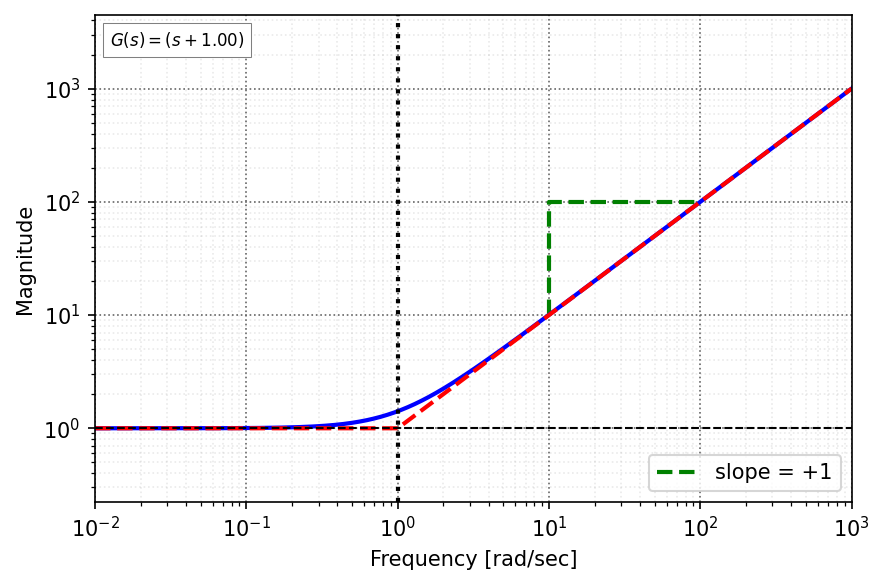

In [33]:
w = np.logspace(-2,3,300)

# full system
G1 = 20*ct.tf([1,1],[1,10]) 

#zero
fig, axs = plt.subplots(figsize=(6,4),dpi=150,sharex=True)
Gz = ct.tf(G1.num[0][0]/G1.num[0][0][1],[1]) 
axs.plot([10,10,100],[10,100,100], 'g--', label='slope = +1')
axs.legend(loc=4)
info = ab.approx_Bode(Gz, w=w, axs=axs, file_name = './figs/L14_approx_z.pdf', mag_only=True)


Saving to ./figs/L14_approx_p.pdf


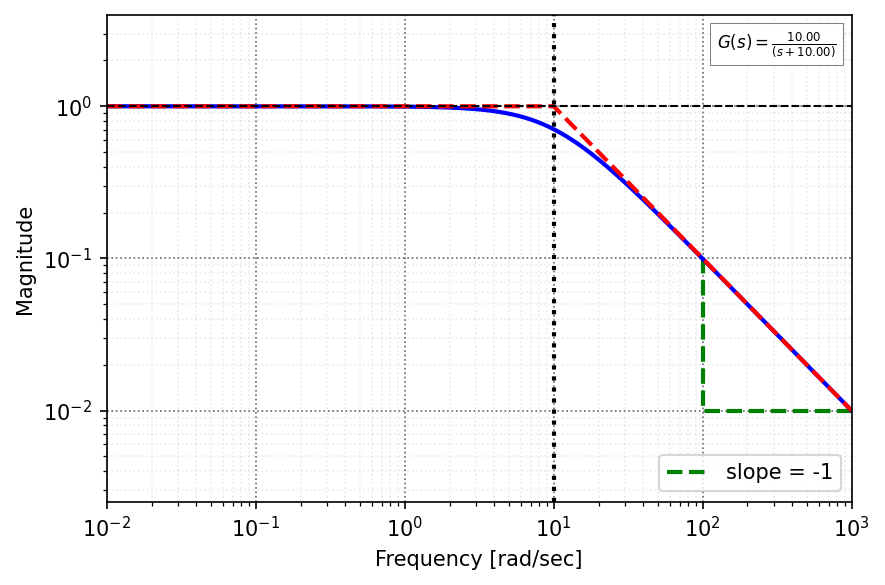

In [34]:
#pole
Gp = ct.tf(1,G1.den[0][0]/G1.den[0][0][1]) 

fig, axs = plt.subplots(figsize=(6,4),dpi=150,sharex=True)
Gz = ct.tf(G1.num[0][0]/G1.num[0][0][1],[1]) 
axs.plot([100,100,1000],[1/10,1/100,1/100], 'g--', label='slope = -1')
axs.legend(loc=4)

info = ab.approx_Bode(Gp, w=w, axs=axs, file_name = './figs/L14_approx_p.pdf', mag_only=True)

Saving to ./figs/L14_approx_pz.pdf


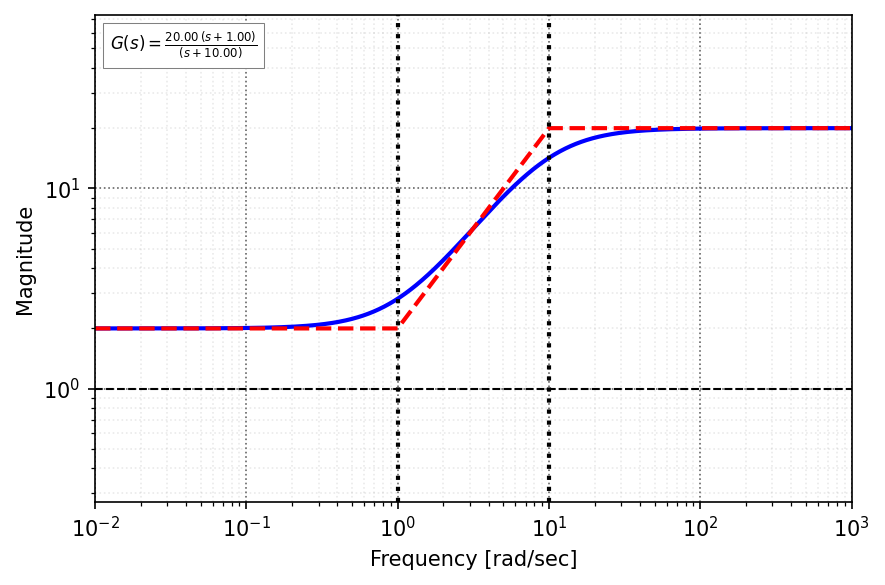

In [35]:
#full
ax = ab.approx_Bode(G1, w=w, file_name = './figs/L14_approx_pz.pdf', mag_only=True)

### Phase Approximations

Saving to ./figs/L14_ph_comp1.pdf
Saving to ./figs/L14_ph_comp2.pdf
Saving to ./figs/L14_ph_comp3.pdf


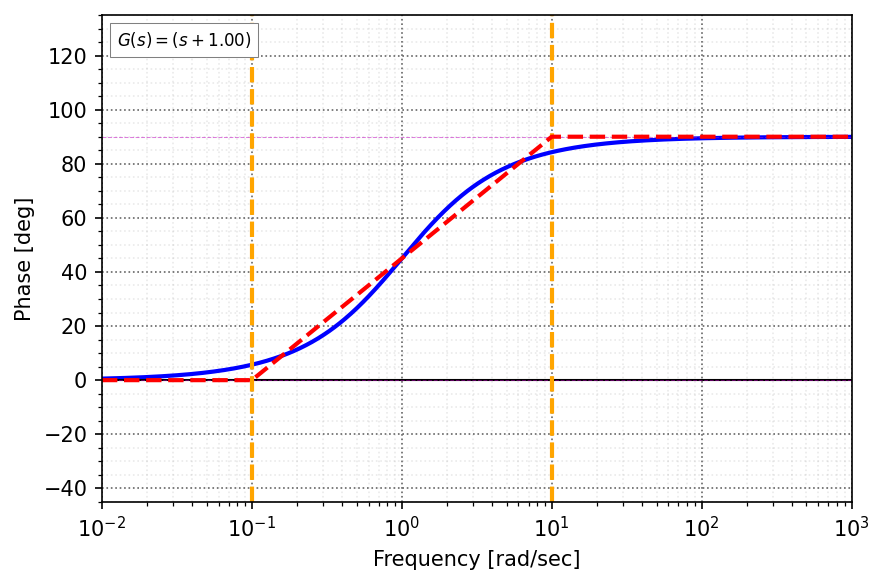

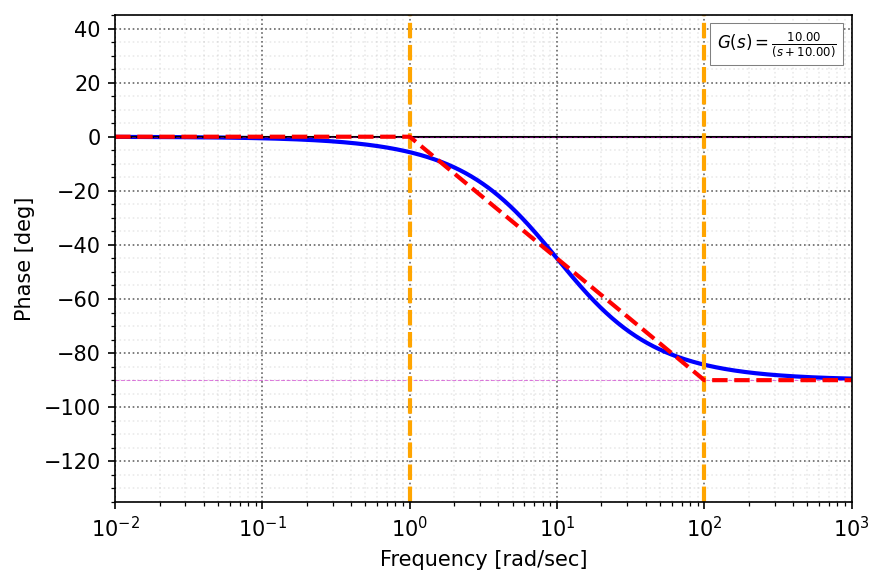

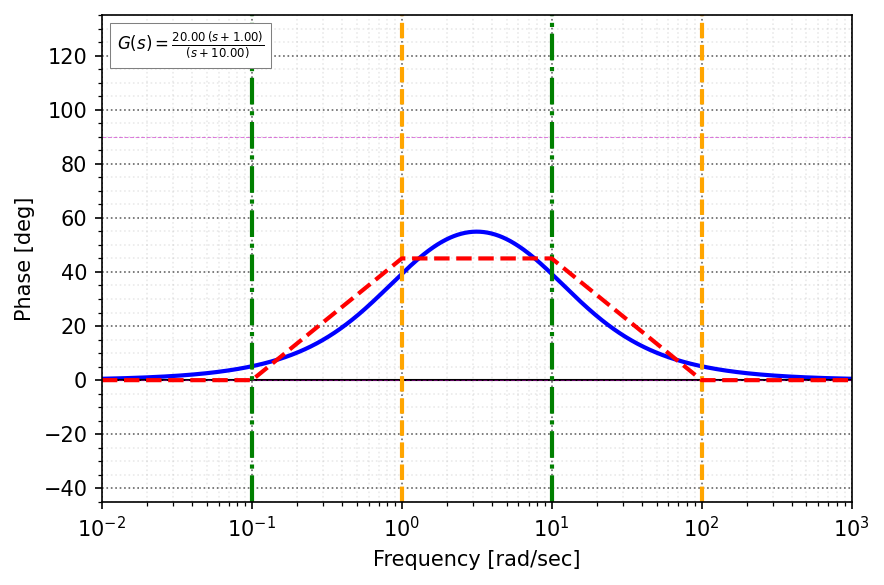

In [36]:
#zero
Gz = ct.tf(G1.num[0][0]/max(G1.num[0][0]),[0,1]) 
ax = ab.approx_Bode(Gz, w=w, file_name = './figs/L14_ph_comp1.pdf', ph_only=True)
#pole
Gp = ct.tf(1,G1.den[0][0]/max(G1.den[0][0])) 
ax = ab.approx_Bode(Gp, w=w, file_name = './figs/L14_ph_comp2.pdf', ph_only=True)
#full
ax = ab.approx_Bode(G1, w=w, file_name = './figs/L14_ph_comp3.pdf', ph_only=True)

## <a id='toc1_2_'></a>[Second Order](#toc0_)

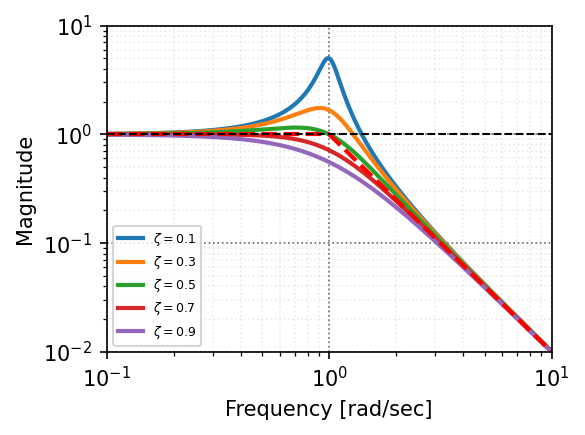

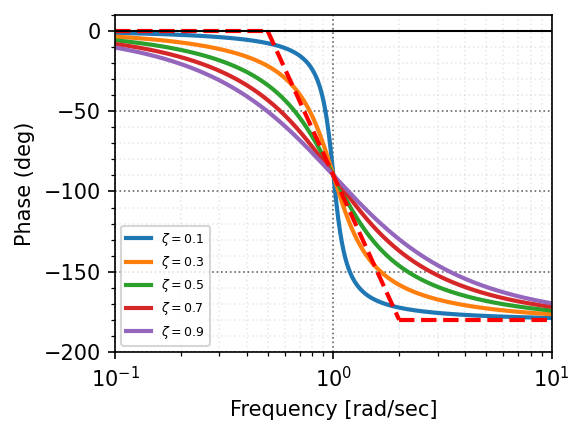

In [37]:
w = np.logspace(-1,1,500)
wi = 1
fig, ax = plt.subplots(1,figsize=(4, 3),dpi=150)
for z in np.arange(.1,1,.2):
    G1 = ct.tf([1],[1,2*z,1]) 
    [G1m,G1p,G1w] = ct.frequency_response(G1,omega=w)
    ax.loglog(G1w,G1m,'-',label=r'$\zeta={:2.1f}$'.format(z))
ax.loglog([min(w),1],[1,1],color='r',ls='--')
ax.loglog([1,10],[1,.01],color='r',ls='--')
ax.loglog([10*wi,max(w)],[90,90],color='r',ls='--')
ax.legend(fontsize=6)
ax.set_ylim([.01,10])
ax.set_xlim([.1,10])
ax.set_ylabel("Magnitude")
ax.set_xlabel("Frequency [rad/sec]") 
bm.nicegrid(ax)
plt.savefig('./figs/L14_sec_ord_mag.pdf',dpi=600)
plt.show()

fig, ax = plt.subplots(1,figsize=(4, 3),dpi=150)
for z in np.arange(.1,1,.2):
    G1 = ct.tf([1],[1,2*z,1]) 
    [G1m,G1p,G1w] = ct.frequency_response(G1,omega=w)
    ax.semilogx(G1w,cm.pshift(G1p)*cm.r2d,'-',label=r'$\zeta={:2.1f}$'.format(z))
ax.semilogx([min(w),1/2],[0,0],color='r',ls='--')
ax.semilogx([1/2,2],[0,-180],color='r',ls='--')
ax.semilogx([2,100],[-180,-180],color='r',ls='--')
ax.legend(fontsize=6)
ax.set_ylim([-200, 10])
ax.set_xlim([.1,10])
ax.set_ylabel("Phase (deg)")
ax.set_xlabel("Frequency [rad/sec]")
bm.nicegrid(ax)
plt.savefig('./figs/L14_sec_ord_ph.pdf',dpi=600)
plt.show()


## <a id='toc1_3_'></a>[Examples 16-20](#toc0_)

Complex pole: -50.0000+0.0000j, cratio: 6.0000
Complex zero: -0.1000+0.9950j, cratio: 1.5000
Saving to ./figs/L14_20act.pdf
Complex pole: -50.0000+0.0000j, cratio: 6.0000
Complex zero: -0.1000+0.9950j, cratio: 1.5000
Saving to ./figs/L14_20a.pdf
Complex zero: -0.0100+0.0995j, cratio: 1.5000
Saving to ./figs/L14_20b.pdf
Saving to ./figs/L14_20c.pdf
Complex pole: -50.0000+0.0000j, cratio: 6.0000
Complex zero: -0.1000+0.9950j, cratio: 1.5000
Saving to ./figs/L14_20d.pdf


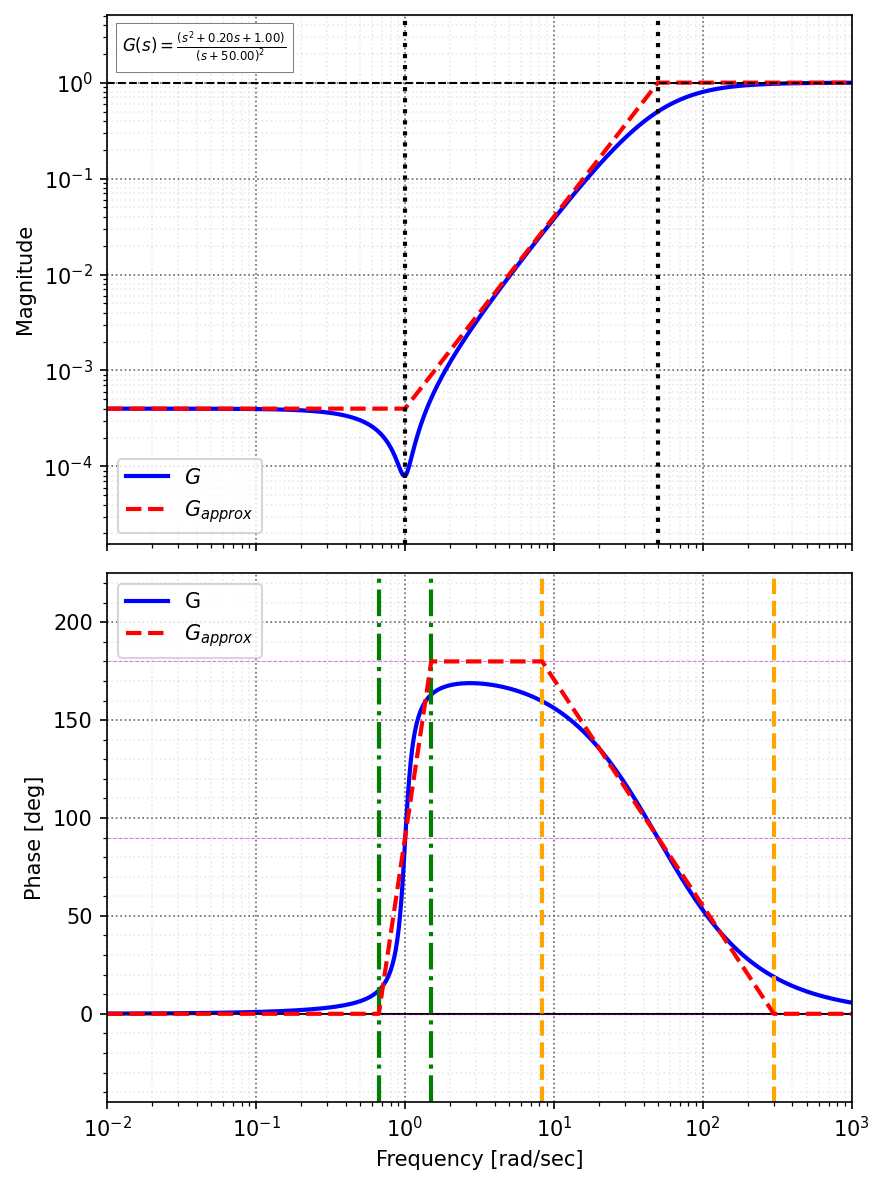

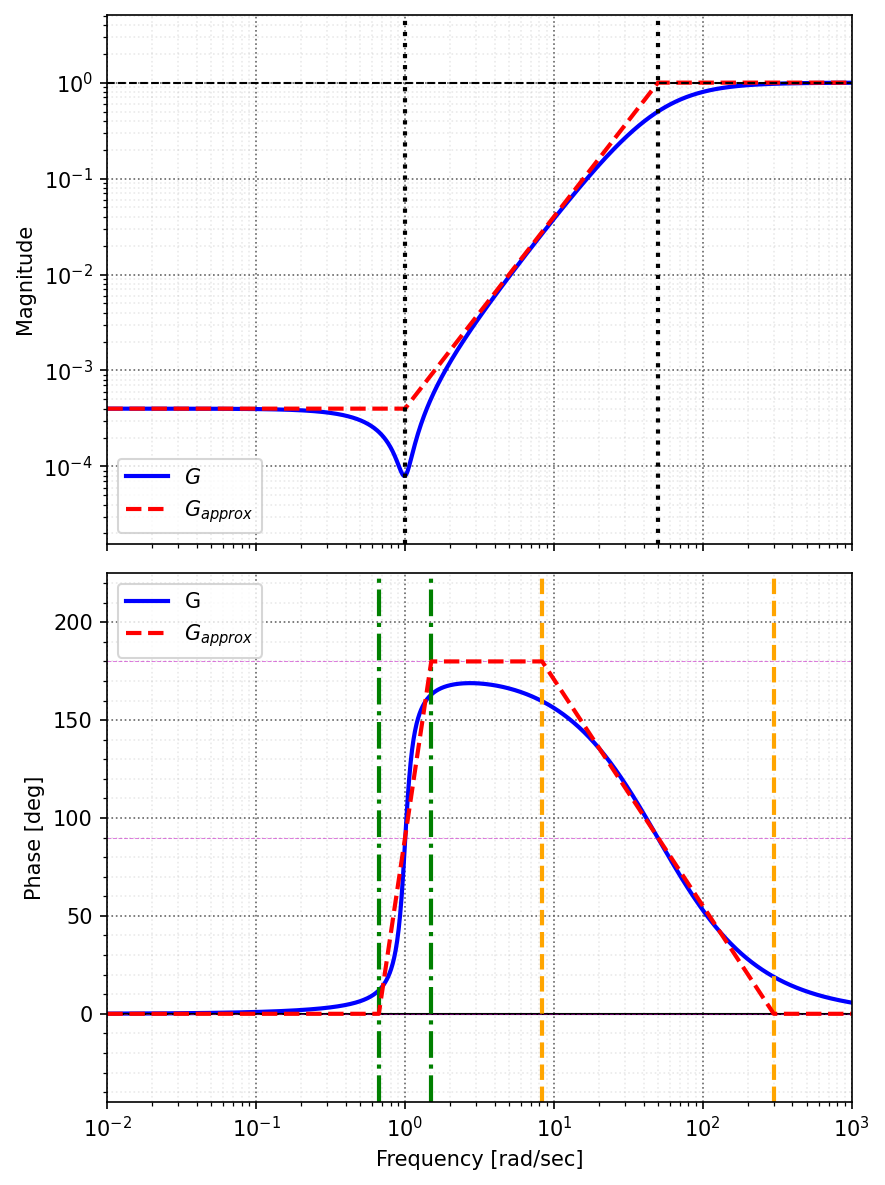

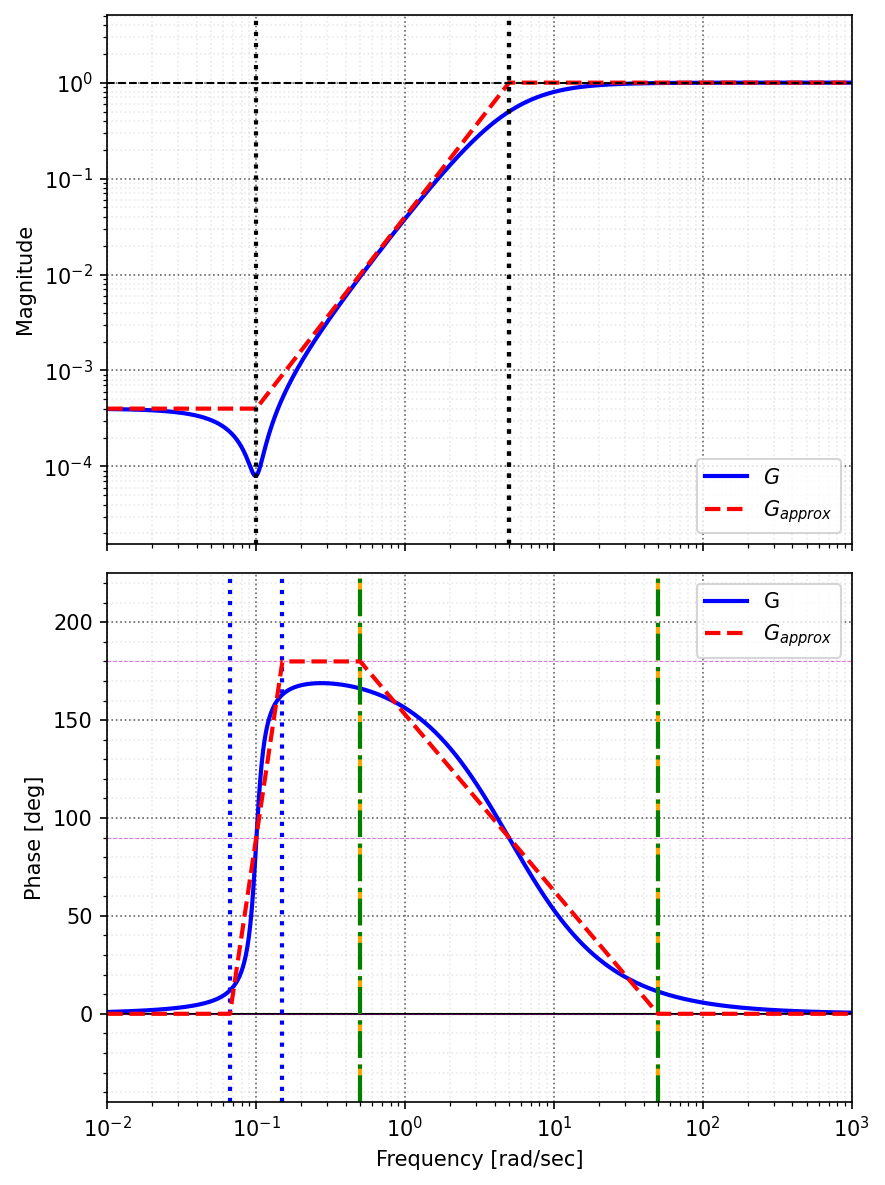

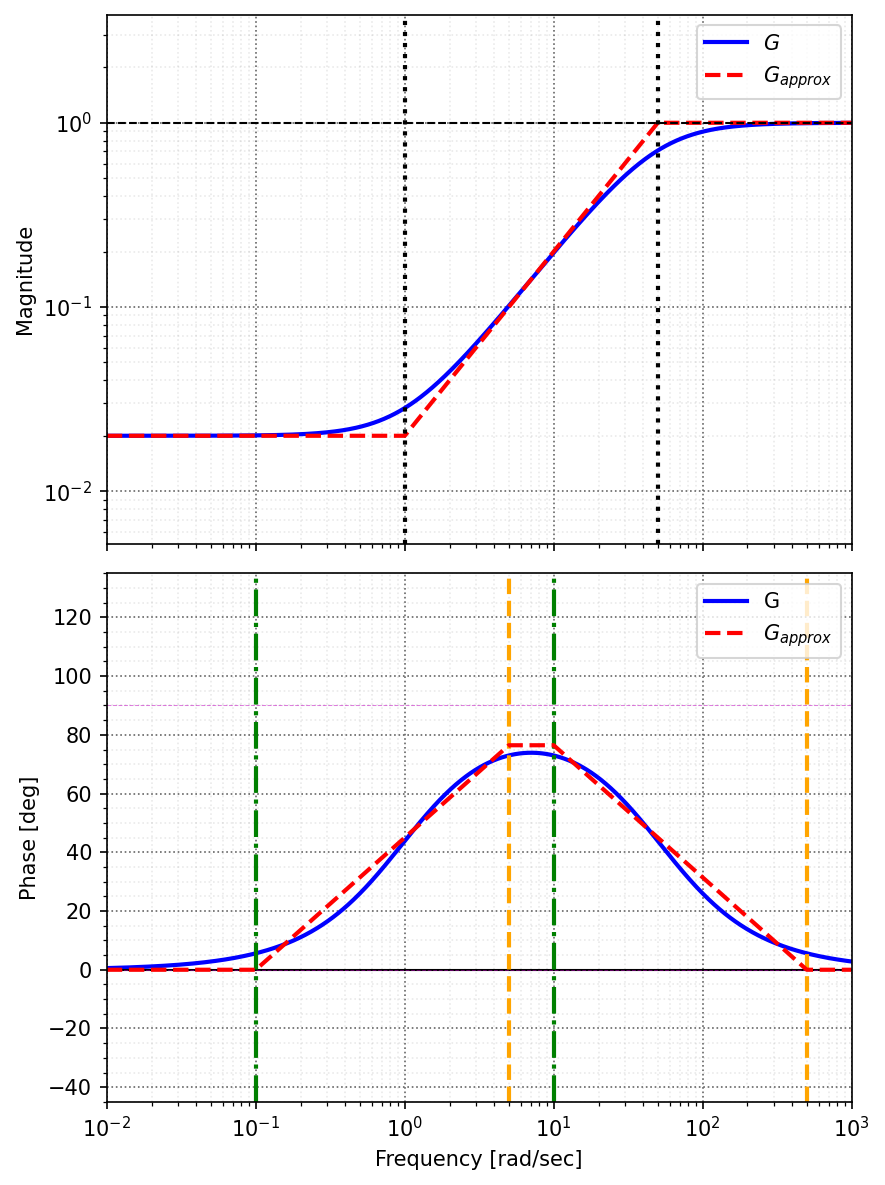

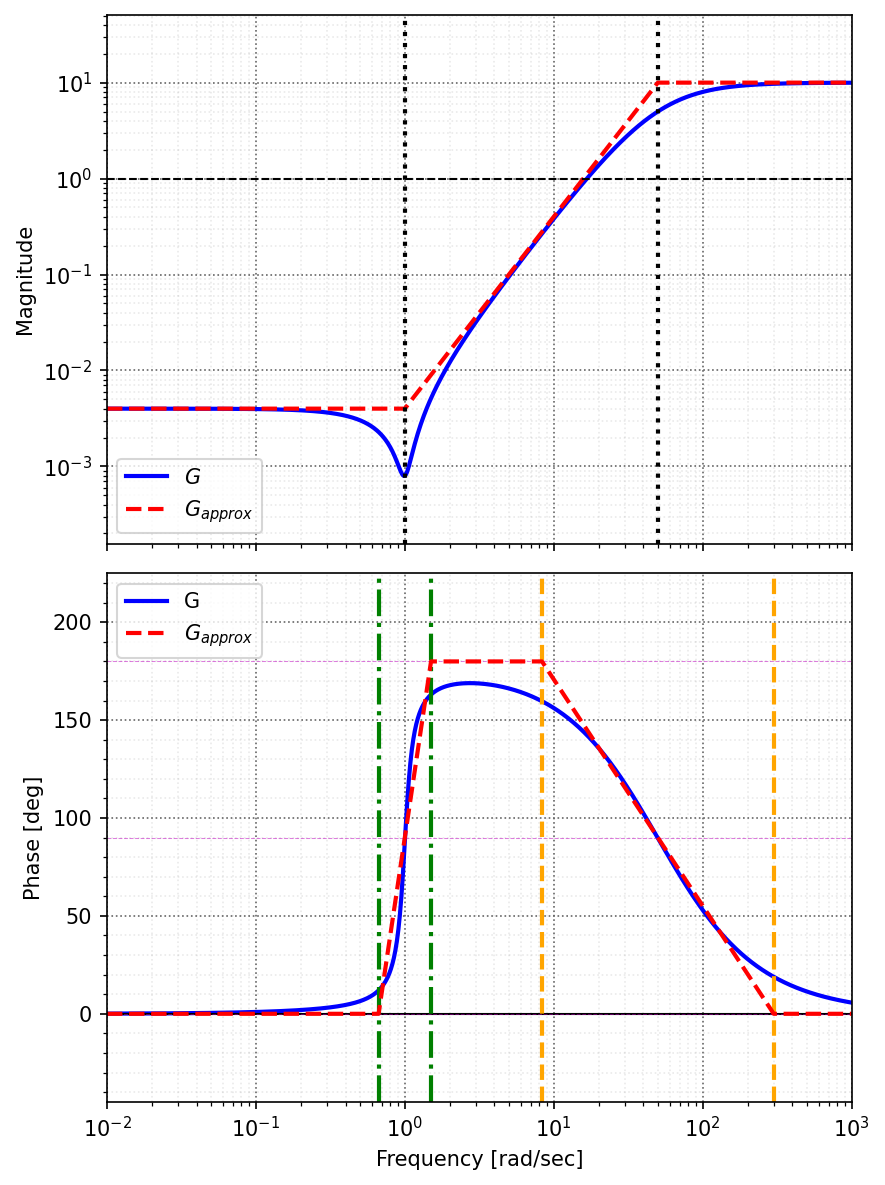

In [38]:
#actual
num=[1, .2*.1, .1**2];den=np.convolve([1, 5],[1, 5])
num=[1, 4];den=np.convolve([1, 50],1)
num=10*[1, .2, 1];den=np.convolve([1, 50],[1, 50])

#filename = "bodas_plot"
s = ct.tf('s')       # define `s` as symbol

Ga = (s**2+0.2*s+1)/(s+50)**2
G1 = (s**2+0.2*.1*s+.1**2)/(s+5)**2
G2 = (s+1)/(s+50)
G3 = 10*(s**2+0.2*s+1)/(s+50)**2

w = np.logspace(-2,3,500)
ax = ab.approx_Bode(Ga, w=w, file_name = './figs/L14_20act.pdf', show_latex=True)
ax = ab.approx_Bode(Ga, w=w, file_name = './figs/L14_20a.pdf', show_latex=False)
ax = ab.approx_Bode(G1, w=w, file_name = './figs/L14_20b.pdf', show_latex=False)
ax = ab.approx_Bode(G2, w=w, file_name = './figs/L14_20c.pdf', show_latex=False)
ax = ab.approx_Bode(G3, w=w, file_name = './figs/L14_20d.pdf', show_latex=False)

## <a id='toc1_4_'></a>[Examples 16-24](#toc0_)

Saving to ./figs/L14_24act.pdf
Saving to ./figs/L14_24a.pdf
Saving to ./figs/L14_24b.pdf
Saving to ./figs/L14_24c.pdf
Saving to ./figs/L14_24d.pdf


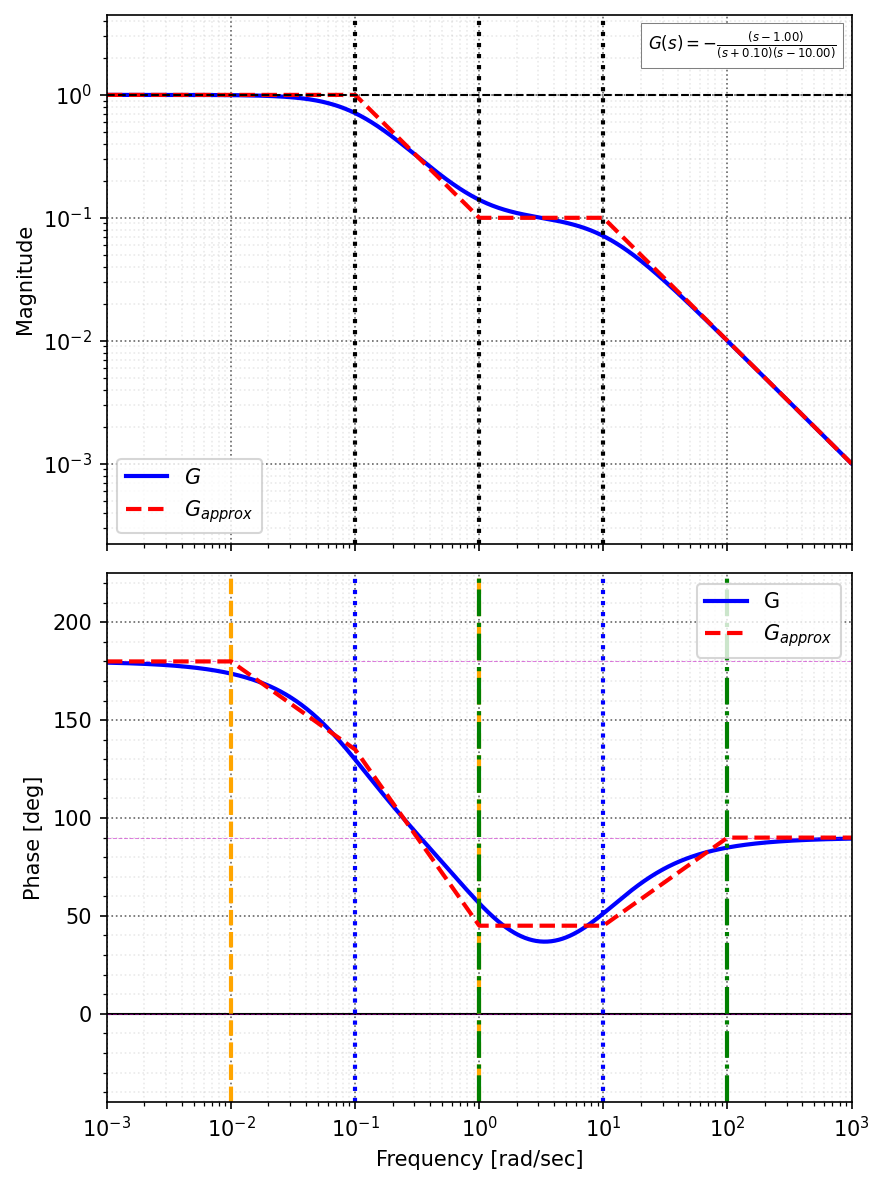

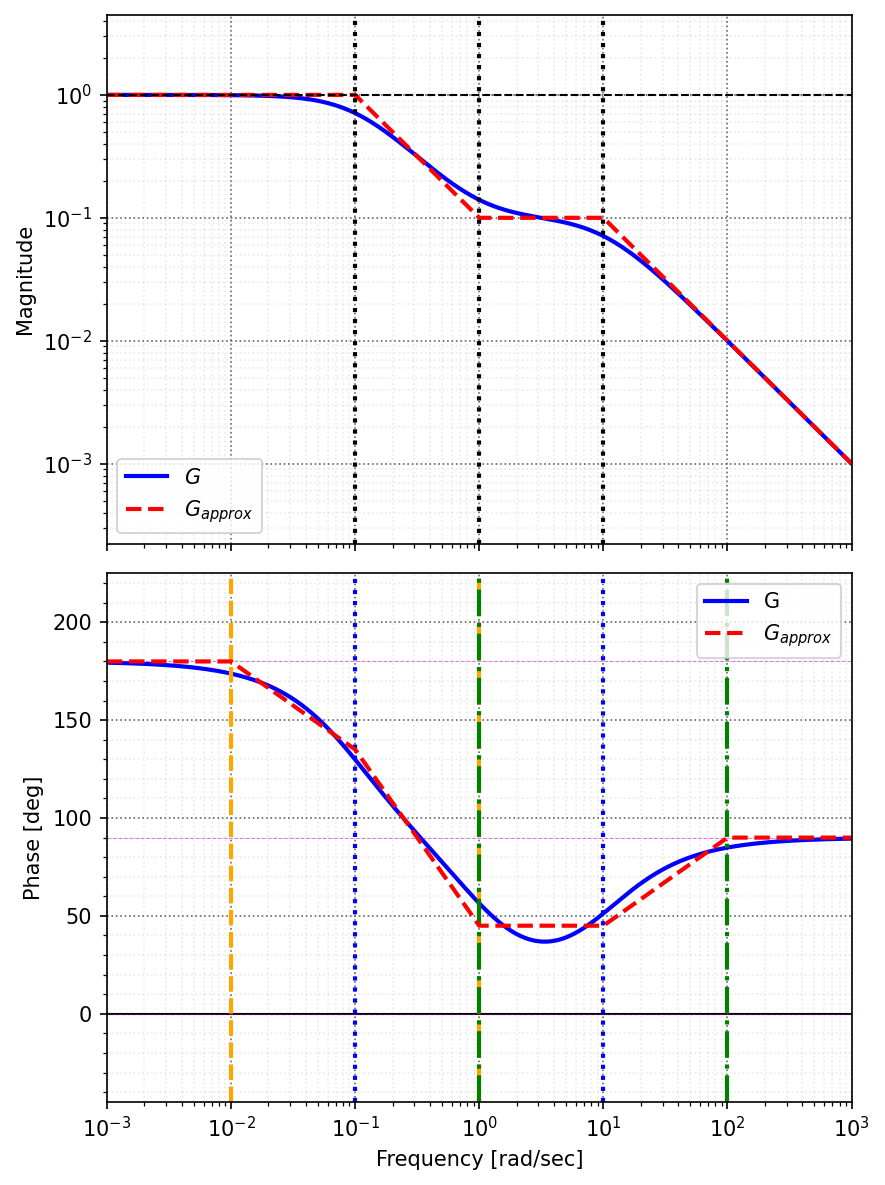

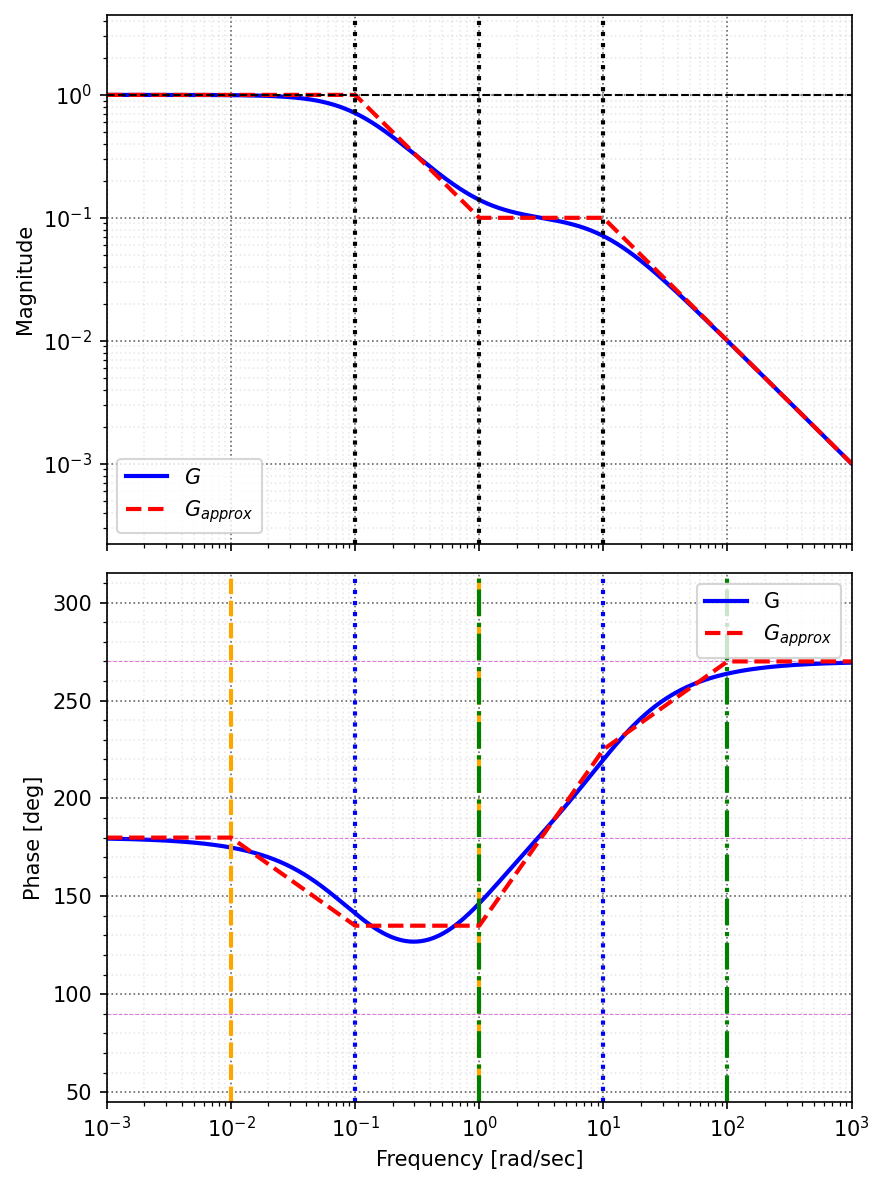

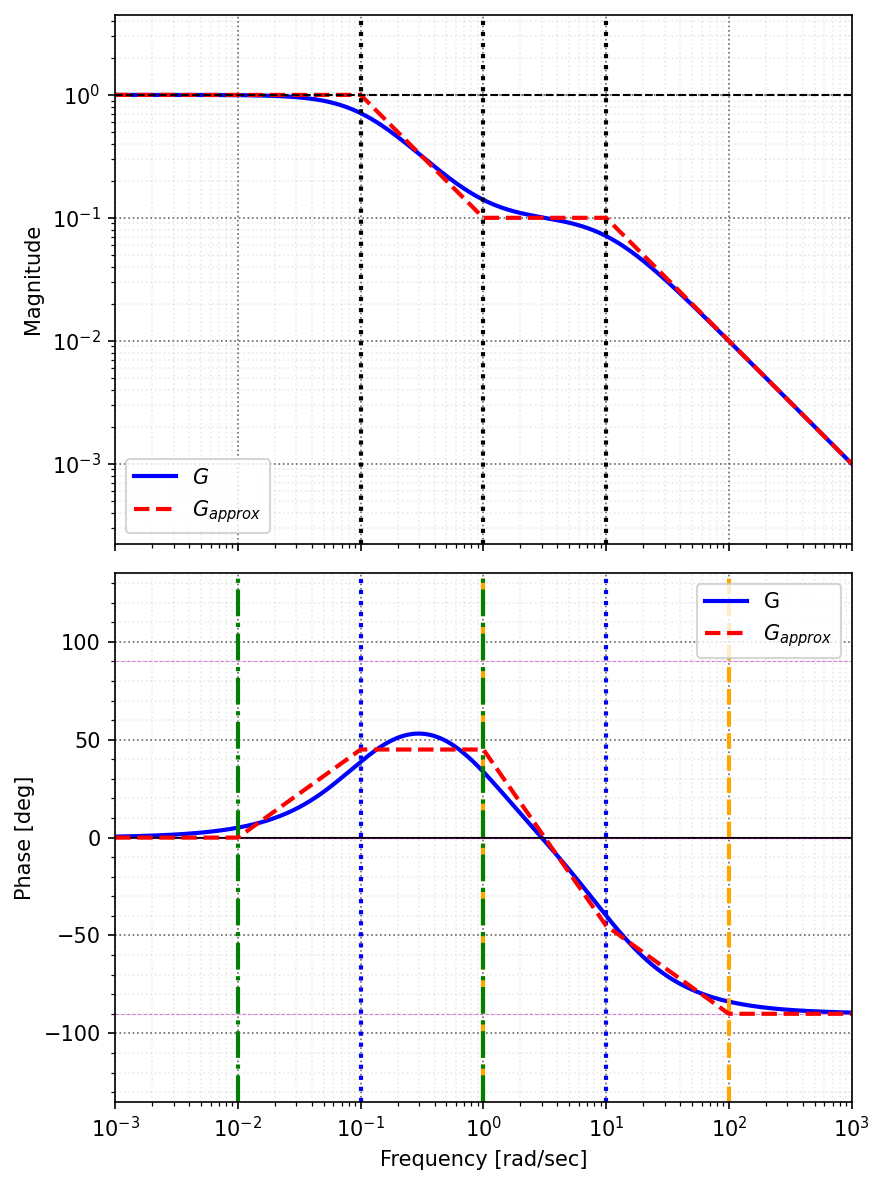

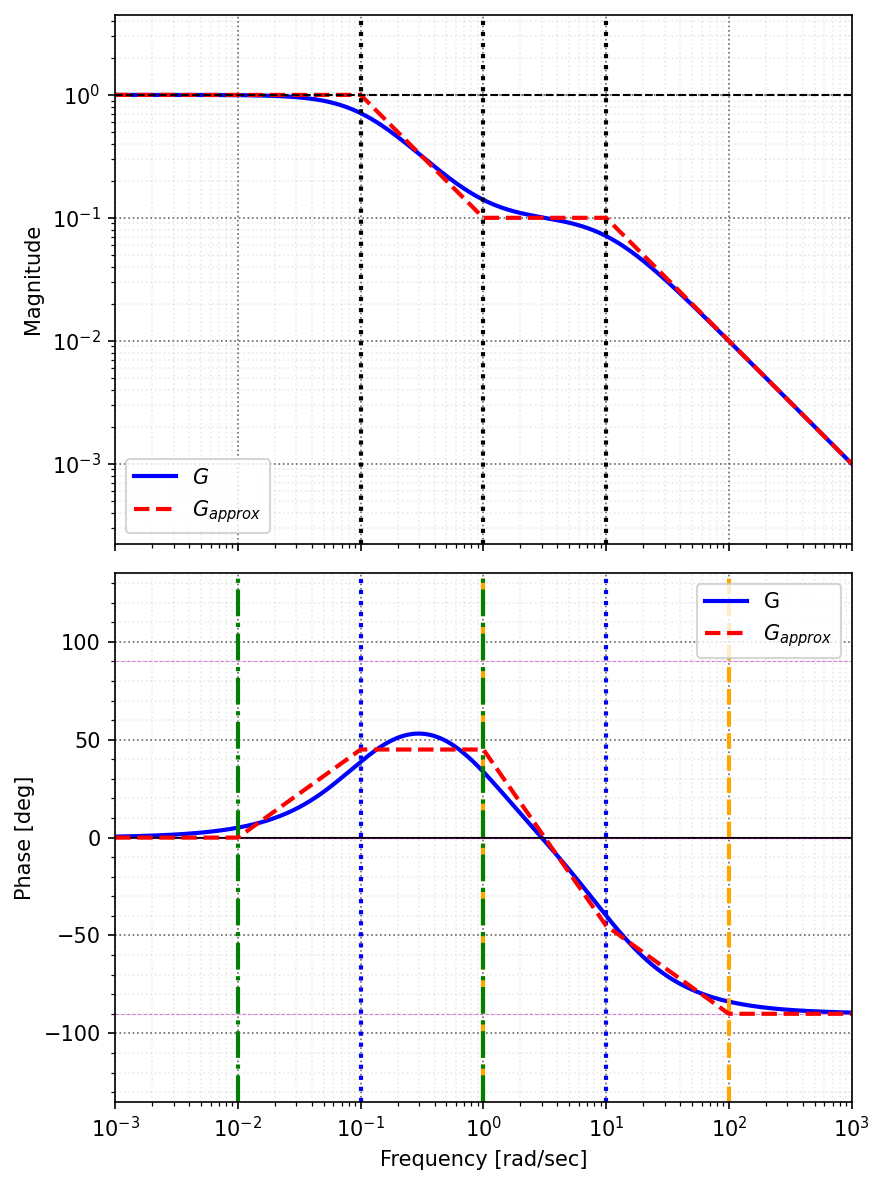

In [39]:
s = ct.tf('s')       # define `s` as symbol
Ga = (-s+1)/(10*s+1)/(0.1*s-1)
G1 = (s+1)/(10*s+1)/(0.1*s-1)
G2 = (-s+1)/(-10*s+1)/(0.1*s+1)
G3 = (-s+1)/(-10*s+1)/(0.1*s+1)

w = np.logspace(-3,3,500)
ax = ab.approx_Bode(Ga, w=w, file_name = './figs/L14_24act.pdf',show_latex=True)
ax = ab.approx_Bode(Ga, w=w, file_name = './figs/L14_24a.pdf',show_latex=False)
ax = ab.approx_Bode(G1, w=w, file_name = './figs/L14_24b.pdf',show_latex=False)
ax = ab.approx_Bode(G2, w=w, file_name = './figs/L14_24c.pdf',show_latex=False)
ax = ab.approx_Bode(G3, w=w, file_name = './figs/L14_24d.pdf',show_latex=False)
